# 🌾 Pest Outbreak Predictor — Indian Agricultural AI System

**Author:** Agricultural AI System  
**Purpose:** Multi-label classification to predict pest outbreak probability over the next 7 days based on weather data, location, crop type, and time of year.  
**Target Crops:** Rice, Wheat, Maize, Tomato, Potato, Onion, Cotton, Sugarcane, Chickpea, Sweetcorn, Garlic, Carrot, Capsicum, Cabbage  
**Target States:** Punjab, Haryana, Uttar Pradesh, Maharashtra, Uttarakhand  
**Data Range:** 2019–2024  

---
## Notebook Structure
1. Install & Import Dependencies
2. Configuration & Constants
3. Data Collection (NASA POWER + iNaturalist)
4. Synthetic Label Generation
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Feature Selection
8. Train/Test Split
9. Model Training & Hyperparameter Tuning
10. Evaluation
11. Save Artifacts
12. Inference Function

## 1. Install & Import Dependencies

In [ ]:
# Install required packages
!pip install xgboost lightgbm tqdm requests joblib scikit-learn pandas numpy matplotlib seaborn --quiet
print('✅ All packages installed.')

✅ All packages installed.


In [ ]:
import os, json, time, warnings, pickle, math, hashlib
from datetime import datetime, timedelta
from collections import defaultdict

import numpy as np
import pandas as pd
import requests
import joblib

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    hamming_loss, accuracy_score, f1_score, roc_auc_score,
    jaccard_score, precision_score, recall_score,
    confusion_matrix
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.feature_selection import mutual_info_classif

from xgboost import XGBClassifier
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All imports successful.')

✅ All imports successful.


## 2. Configuration & Constants

District coordinates, crop-pest mappings, pest agronomic thresholds, and pest taxa definitions.

In [ ]:
# ─── District Coordinates ───────────────────────────────────────────────────
DISTRICTS = {
    'Punjab': [
        {'name': 'Ludhiana',    'lat': 30.9010, 'lon': 75.8573},
        {'name': 'Amritsar',    'lat': 31.6340, 'lon': 74.8723},
        {'name': 'Bathinda',    'lat': 30.2110, 'lon': 74.9455},
    ],
    'Haryana': [
        {'name': 'Karnal',      'lat': 29.6857, 'lon': 76.9905},
        {'name': 'Hisar',       'lat': 29.1492, 'lon': 75.7217},
        {'name': 'Rohtak',      'lat': 28.8955, 'lon': 76.6066},
    ],
    'Uttar Pradesh': [
        {'name': 'Lucknow',     'lat': 26.8467, 'lon': 80.9462},
        {'name': 'Agra',        'lat': 27.1767, 'lon': 78.0081},
        {'name': 'Gorakhpur',   'lat': 26.7606, 'lon': 83.3732},
    ],
    'Maharashtra': [
        {'name': 'Pune',        'lat': 18.5204, 'lon': 73.8567},
        {'name': 'Nagpur',      'lat': 21.1458, 'lon': 79.0882},
        {'name': 'Nashik',      'lat': 19.9975, 'lon': 73.7898},
    ],
    'Uttarakhand': [
        {'name': 'Dehradun',    'lat': 30.3165, 'lon': 78.0322},
        {'name': 'Haridwar',    'lat': 29.9457, 'lon': 78.1642},
        {'name': 'Udham Singh Nagar', 'lat': 28.9669, 'lon': 79.5021},
    ],
}

# ─── Date Range ──────────────────────────────────────────────────────────────
START_DATE = '2019-01-01'
END_DATE   = '2024-12-31'

# ─── Pest Classes ────────────────────────────────────────────────────────────
PEST_CLASSES = [
    'Aphids', 'Whitefly', 'Stem_Borer', 'Fall_Armyworm',
    'Brown_Planthopper', 'Thrips', 'Leaf_Miner', 'Spider_Mites',
    'Diamondback_Moth', 'Early_Blight', 'Powdery_Mildew', 'Cutworm'
]

# ─── Crop-Pest Mapping ───────────────────────────────────────────────────────
CROP_PEST_MAPPING = {
    'Rice':       ['Stem_Borer', 'Brown_Planthopper', 'Leaf_Miner', 'Thrips', 'Whitefly'],
    'Wheat':      ['Aphids', 'Stem_Borer', 'Thrips', 'Powdery_Mildew', 'Cutworm'],
    'Maize':      ['Fall_Armyworm', 'Stem_Borer', 'Aphids', 'Cutworm', 'Spider_Mites'],
    'Tomato':     ['Whitefly', 'Aphids', 'Thrips', 'Early_Blight', 'Leaf_Miner', 'Spider_Mites'],
    'Potato':     ['Aphids', 'Whitefly', 'Early_Blight', 'Cutworm', 'Thrips'],
    'Onion':      ['Thrips', 'Leaf_Miner', 'Cutworm', 'Aphids'],
    'Cotton':     ['Whitefly', 'Aphids', 'Thrips', 'Spider_Mites', 'Stem_Borer'],
    'Sugarcane':  ['Stem_Borer', 'Aphids', 'Cutworm', 'Whitefly'],
    'Chickpea':   ['Aphids', 'Cutworm', 'Thrips', 'Powdery_Mildew'],
    'Sweetcorn':  ['Fall_Armyworm', 'Stem_Borer', 'Aphids', 'Spider_Mites'],
    'Garlic':     ['Thrips', 'Leaf_Miner', 'Aphids'],
    'Carrot':     ['Aphids', 'Leaf_Miner', 'Cutworm'],
    'Capsicum':   ['Aphids', 'Thrips', 'Whitefly', 'Spider_Mites', 'Early_Blight'],
    'Cabbage':    ['Diamondback_Moth', 'Aphids', 'Cutworm', 'Whitefly', 'Thrips'],
}

# ─── iNaturalist Taxon IDs ────────────────────────────────────────────────────
INAT_TAXA = {
    'Aphids':             48734,
    'Whitefly':           126405,
    'Stem_Borer':         None,   # will use keyword search
    'Fall_Armyworm':      717707,
    'Brown_Planthopper':  119019,
    'Thrips':             49788,
    'Leaf_Miner':         None,
    'Spider_Mites':       71583,
    'Diamondback_Moth':   215561,
    'Early_Blight':       None,   # fungal, limited iNat data
    'Powdery_Mildew':     None,
    'Cutworm':            None,
}

# ─── Agronomic Outbreak Rules ─────────────────────────────────────────────────
# Each rule: (temp_min, temp_max, humidity_min, humidity_max, consec_days)
PEST_RULES = {
    'Aphids':             dict(t_min=15, t_max=28, rh_min=60, rh_max=100, rain_max=20),
    'Whitefly':           dict(t_min=24, t_max=36, rh_min=55, rh_max=100, rain_max=15),
    'Stem_Borer':         dict(t_min=25, t_max=35, rh_min=70, rh_max=100, rain_max=50),
    'Fall_Armyworm':      dict(t_min=20, t_max=35, rh_min=60, rh_max=100, rain_max=40),
    'Brown_Planthopper':  dict(t_min=22, t_max=32, rh_min=80, rh_max=100, rain_max=60),
    'Thrips':             dict(t_min=20, t_max=32, rh_min=40, rh_max=70,  rain_max=10),
    'Leaf_Miner':         dict(t_min=18, t_max=30, rh_min=50, rh_max=80,  rain_max=15),
    'Spider_Mites':       dict(t_min=27, t_max=42, rh_min=20, rh_max=55,  rain_max=5),
    'Diamondback_Moth':   dict(t_min=16, t_max=30, rh_min=60, rh_max=90,  rain_max=20),
    'Early_Blight':       dict(t_min=24, t_max=32, rh_min=80, rh_max=100, rain_max=70),
    'Powdery_Mildew':     dict(t_min=15, t_max=28, rh_min=50, rh_max=75,  rain_max=5),
    'Cutworm':            dict(t_min=10, t_max=28, rh_min=50, rh_max=85,  rain_max=30),
}

LABEL_NOISE = 0.08  # 8% label noise

CACHE_DIR = '/content/weather_cache'
os.makedirs(CACHE_DIR, exist_ok=True)
print('✅ Configuration loaded.')
print(f'   Districts: {sum(len(v) for v in DISTRICTS.values())} across {len(DISTRICTS)} states')
print(f'   Pest classes: {len(PEST_CLASSES)}')
print(f'   Crops: {len(CROP_PEST_MAPPING)}')

✅ Configuration loaded.
   Districts: 15 across 5 states
   Pest classes: 12
   Crops: 14


## 3. Data Collection

### 3a. NASA POWER API — Historical Weather (2019–2024)

Fetches daily weather parameters for each district. Results are cached as JSON files so re-runs skip API calls.

In [ ]:
def fetch_nasa_power(lat, lon, start, end, retries=3, delay=5):
    """
    Fetch daily weather from NASA POWER API.
    Parameters: T2M, T2M_MAX, T2M_MIN, RH2M, PRECTOTCORR, WS2M, ALLSKY_SFC_SW_DWN
    """
    cache_key = hashlib.md5(f'{lat}_{lon}_{start}_{end}'.encode()).hexdigest()
    cache_path = os.path.join(CACHE_DIR, f'nasa_{cache_key}.json')

    if os.path.exists(cache_path):
        with open(cache_path) as f:
            return json.load(f)

    params = {
        'parameters': 'T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN',
        'community': 'AG',
        'longitude': lon,
        'latitude': lat,
        'start': start.replace('-', ''),
        'end': end.replace('-', ''),
        'format': 'JSON'
    }
    url = 'https://power.larc.nasa.gov/api/temporal/daily/point'

    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, timeout=60)
            r.raise_for_status()
            data = r.json()
            with open(cache_path, 'w') as f:
                json.dump(data, f)
            return data
        except Exception as e:
            print(f'    ⚠ Attempt {attempt+1} failed: {e}')
            if attempt < retries - 1:
                time.sleep(delay)
    print(f'    ✗ All retries failed for ({lat}, {lon})')
    return None


def parse_nasa_response(data, district_name, state_name):
    """Parse NASA POWER JSON response into a tidy DataFrame."""
    if data is None:
        return pd.DataFrame()
    try:
        props = data['properties']['parameter']
        dates = list(props['T2M'].keys())
        df = pd.DataFrame({
            'date':      pd.to_datetime(dates, format='%Y%m%d'),
            't_avg':     list(props['T2M'].values()),
            't_max':     list(props['T2M_MAX'].values()),
            't_min':     list(props['T2M_MIN'].values()),
            'humidity':  list(props['RH2M'].values()),
            'rainfall':  list(props['PRECTOTCORR'].values()),
            'wind':      list(props['WS2M'].values()),
            'solar_rad': list(props['ALLSKY_SFC_SW_DWN'].values()),
        })
        df['district'] = district_name
        df['state']    = state_name
        # Replace NASA fill value (-999)
        df.replace(-999.0, np.nan, inplace=True)
        df.replace(-999,   np.nan, inplace=True)
        return df
    except Exception as e:
        print(f'    Parse error for {district_name}: {e}')
        return pd.DataFrame()


print('Fetching NASA POWER weather data for all districts (2019–2024)...')
print('Results are cached — first run may take ~10-15 minutes.\n')

all_weather_frames = []

for state, districts in DISTRICTS.items():
    for district in tqdm(districts, desc=f'{state}'):
        name = district['name']
        lat  = district['lat']
        lon  = district['lon']
        print(f'  → Fetching {name} ({state})  lat={lat}, lon={lon}')
        raw = fetch_nasa_power(lat, lon, START_DATE, END_DATE)
        df  = parse_nasa_response(raw, name, state)
        if not df.empty:
            all_weather_frames.append(df)
            print(f'    ✓ {len(df)} days fetched')
        else:
            print(f'    ✗ No data returned for {name}')

weather_df = pd.concat(all_weather_frames, ignore_index=True)
weather_df.sort_values(['district', 'date'], inplace=True)
weather_df.reset_index(drop=True, inplace=True)

print(f'\n✅ Weather data collected: {weather_df.shape}')
print(weather_df.head(3))

Fetching NASA POWER weather data for all districts (2019–2024)...
Results are cached — first run may take ~10-15 minutes.



Punjab:   0%|          | 0/3 [00:00<?, ?it/s]

  → Fetching Ludhiana (Punjab)  lat=30.901, lon=75.8573
    ✓ 2192 days fetched
  → Fetching Amritsar (Punjab)  lat=31.634, lon=74.8723
    ✓ 2192 days fetched
  → Fetching Bathinda (Punjab)  lat=30.211, lon=74.9455
    ✓ 2192 days fetched


Haryana:   0%|          | 0/3 [00:00<?, ?it/s]

  → Fetching Karnal (Haryana)  lat=29.6857, lon=76.9905
    ✓ 2192 days fetched
  → Fetching Hisar (Haryana)  lat=29.1492, lon=75.7217
    ✓ 2192 days fetched
  → Fetching Rohtak (Haryana)  lat=28.8955, lon=76.6066
    ✓ 2192 days fetched


...

  → Fetching Lucknow (Uttar Pradesh)  lat=26.8467, lon=80.9462
    ✓ 2192 days fetched
  → Fetching Agra (Uttar Pradesh)  lat=27.1767, lon=78.0081
    ✓ 2192 days fetched
  → Fetching Gorakhpur (Uttar Pradesh)  lat=26.7606, lon=83.3732
    ✓ 2192 days fetched


Maharashtra:   0%|          | 0/3 [00:00<?, ?it/s]

  → Fetching Pune (Maharashtra)  lat=18.5204, lon=73.8567
    ✓ 2192 days fetched
  → Fetching Nagpur (Maharashtra)  lat=21.1458, lon=79.0882
    ✓ 2192 days fetched
  → Fetching Nashik (Maharashtra)  lat=19.9975, lon=73.7898
    ✓ 2192 days fetched


Uttarakhand:   0%|          | 0/3 [00:00<?, ?it/s]

  → Fetching Dehradun (Uttarakhand)  lat=30.3165, lon=78.0322
    ✓ 2192 days fetched
  → Fetching Haridwar (Uttarakhand)  lat=29.9457, lon=78.1642
    ✓ 2192 days fetched
  → Fetching Udham Singh Nagar (Uttarakhand)  lat=28.9669, lon=79.5021
    ✓ 2192 days fetched

✅ Weather data collected: (32880, 10)
        date  t_avg  t_max  t_min  humidity  rainfall  wind  solar_rad  \
0 2019-01-01  14.00  23.64   7.57     36.75       0.0  0.98      12.62   
1 2019-01-02  13.69  23.60   6.15     45.24       0.0  1.24      10.97   
2 2019-01-03  13.98  23.08   6.66     43.75       0.0  1.36      11.25   

  district          state  
0     Agra  Uttar Pradesh  
1     Agra  Uttar Pradesh  
2     Agra  Uttar Pradesh  


### 3b. iNaturalist API — Pest Observations (India, 2019–2024)

Pulls confirmed pest observations for India. Since rural coverage is sparse, these will be used to *override* synthetic labels where real observations exist.

In [ ]:
INAT_CACHE = os.path.join(CACHE_DIR, 'inat_observations.json')

def fetch_inat_observations(taxon_id, taxon_name, lat, lon, radius_km=50,
                             d1='2019-01-01', d2='2024-12-31',
                             retries=3, delay=5):
    """
    Fetch observations from iNaturalist for a given taxon near lat/lon.
    Returns list of dicts with date and location.
    """
    if taxon_id is None:
        return []

    observations = []
    page = 1
    per_page = 200

    while True:
        url = 'https://api.inaturalist.org/v1/observations'
        params = {
            'taxon_id': taxon_id,
            'lat': lat, 'lng': lon,
            'radius': radius_km,
            'd1': d1, 'd2': d2,
            'quality_grade': 'research',
            'per_page': per_page,
            'page': page,
        }
        for attempt in range(retries):
            try:
                r = requests.get(url, params=params, timeout=30)
                r.raise_for_status()
                data = r.json()
                break
            except Exception as e:
                if attempt < retries - 1:
                    time.sleep(delay)
                else:
                    return observations

        results = data.get('results', [])
        if not results:
            break
        for obs in results:
            if obs.get('observed_on'):
                observations.append({
                    'date': obs['observed_on'],
                    'lat': obs.get('location', '0,0').split(',')[0],
                    'lon': obs.get('location', '0,0').split(',')[1],
                    'pest': taxon_name,
                    'confirmed': 1
                })
        if len(results) < per_page:
            break
        page += 1
        time.sleep(1)  # rate limit courtesy

    return observations


if os.path.exists(INAT_CACHE):
    print('Loading iNaturalist observations from cache...')
    with open(INAT_CACHE) as f:
        all_inat = json.load(f)
else:
    print('Fetching iNaturalist observations (may be sparse for rural India)...')
    all_inat = []
    # Use bounding box for India roughly
    # We sample from a few representative lat/lon per state
    sample_coords = [
        (30.9, 75.8),   # Punjab
        (29.6, 76.9),   # Haryana
        (26.8, 80.9),   # UP
        (18.5, 73.8),   # Maharashtra
        (30.3, 78.0),   # Uttarakhand
    ]

    for pest_name, taxon_id in tqdm(INAT_TAXA.items(), desc='iNaturalist taxa'):
        if taxon_id is None:
            continue
        for lat, lon in sample_coords:
            obs = fetch_inat_observations(taxon_id, pest_name, lat, lon)
            all_inat.extend(obs)
            print(f'  {pest_name} @ ({lat},{lon}): {len(obs)} observations')

    with open(INAT_CACHE, 'w') as f:
        json.dump(all_inat, f)

inat_df = pd.DataFrame(all_inat) if all_inat else pd.DataFrame(columns=['date','lat','lon','pest','confirmed'])
if not inat_df.empty:
    inat_df['date'] = pd.to_datetime(inat_df['date'])

print(f'\n✅ iNaturalist observations: {len(inat_df)} total')
if not inat_df.empty:
    print(inat_df['pest'].value_counts())

Fetching iNaturalist observations (may be sparse for rural India)...


iNaturalist taxa:   0%|          | 0/12 [00:00<?, ?it/s]

  Aphids @ (30.9,75.8): 0 observations
  Aphids @ (29.6,76.9): 0 observations
  Aphids @ (26.8,80.9): 0 observations
  Aphids @ (18.5,73.8): 0 observations
  Aphids @ (30.3,78.0): 0 observations
  Whitefly @ (30.9,75.8): 0 observations
  Whitefly @ (29.6,76.9): 0 observations
  Whitefly @ (26.8,80.9): 0 observations
  Whitefly @ (18.5,73.8): 6 observations
  Whitefly @ (30.3,78.0): 4 observations
  Fall_Armyworm @ (30.9,75.8): 0 observations
  Fall_Armyworm @ (29.6,76.9): 0 observations
  Fall_Armyworm @ (26.8,80.9): 0 observations
  Fall_Armyworm @ (18.5,73.8): 0 observations
  Fall_Armyworm @ (30.3,78.0): 0 observations
  Brown_Planthopper @ (30.9,75.8): 0 observations
  Brown_Planthopper @ (29.6,76.9): 0 observations
  Brown_Planthopper @ (26.8,80.9): 0 observations
  Brown_Planthopper @ (18.5,73.8): 0 observations
  Brown_Planthopper @ (30.3,78.0): 7 observations
  Thrips @ (30.9,75.8): 0 observations
  Thrips @ (29.6,76.9): 0 observations
  Thrips @ (26.8,80.9): 0 observations
  T

## 4. Synthetic Label Generation

Since iNaturalist data is sparse for rural India, we generate pest outbreak labels using documented agronomic rules. 8% label noise is added. Real iNaturalist observations override synthetic labels.

In [ ]:
def compute_rolling_stats(df):
    """
    Compute 7-day rolling averages of t_avg, humidity, rainfall sum
    per district for use in label generation.
    """
    df = df.sort_values(['district', 'date']).copy()
    grp = df.groupby('district')
    df['t_avg_7d']    = grp['t_avg'].transform(lambda x: x.rolling(7, min_periods=3).mean())
    df['rh_7d']       = grp['humidity'].transform(lambda x: x.rolling(7, min_periods=3).mean())
    df['rain_7d']     = grp['rainfall'].transform(lambda x: x.rolling(7, min_periods=3).sum())
    return df


def apply_pest_rules(row):
    """
    Apply agronomic rules to generate binary pest outbreak labels.
    Returns dict of {pest: 0/1}
    """
    labels = {}
    t = row.get('t_avg_7d', np.nan)
    rh = row.get('rh_7d', np.nan)
    rain = row.get('rain_7d', np.nan)

    if pd.isna(t) or pd.isna(rh) or pd.isna(rain):
        return {p: 0 for p in PEST_CLASSES}

    for pest, rule in PEST_RULES.items():
        outbreak = int(
            rule['t_min'] <= t <= rule['t_max'] and
            rule['rh_min'] <= rh <= rule['rh_max'] and
            rain <= rule['rain_max']
        )
        labels[pest] = outbreak
    return labels


print('Computing rolling stats for label generation...')
weather_df = compute_rolling_stats(weather_df)

print('Generating synthetic pest outbreak labels...')
label_rows = []
for _, row in tqdm(weather_df.iterrows(), total=len(weather_df), desc='Labelling rows'):
    label_rows.append(apply_pest_rules(row))

label_df = pd.DataFrame(label_rows, columns=PEST_CLASSES)

# ─── Add 8% Label Noise ──────────────────────────────────────────────────────
print('Adding 8% label noise...')
rng = np.random.default_rng(RANDOM_STATE)
noise_mask = rng.random(label_df.shape) < LABEL_NOISE
label_df = label_df.astype(int)
label_df = label_df ^ noise_mask.astype(int)  # XOR flip
label_df = label_df.clip(0, 1)

# ─── Override with iNaturalist Observations ──────────────────────────────────
if not inat_df.empty:
    print('Overriding with confirmed iNaturalist observations...')
    override_count = 0
    weather_df_reset = weather_df.reset_index(drop=True)
    for _, obs in inat_df.iterrows():
        pest = obs['pest']
        if pest not in PEST_CLASSES:
            continue
        obs_date = obs['date']
        # Match weather rows within ±3 days
        mask = (
            (weather_df_reset['date'] >= obs_date - pd.Timedelta(days=3)) &
            (weather_df_reset['date'] <= obs_date + pd.Timedelta(days=3))
        )
        idx = weather_df_reset[mask].index.tolist()
        for i in idx:
            label_df.at[i, pest] = 1
            override_count += 1
    print(f'  ✓ {override_count} label cells overridden with real observations.')

# Concatenate
master_df = pd.concat([weather_df.reset_index(drop=True), label_df], axis=1)
master_df.dropna(subset=['t_avg', 'humidity'], inplace=True)
master_df.reset_index(drop=True, inplace=True)

print(f'\n✅ Master dataset shape: {master_df.shape}')
print('Label prevalence (% days with outbreak):')
print((master_df[PEST_CLASSES].mean() * 100).round(1).to_string())

Computing rolling stats for label generation...
Generating synthetic pest outbreak labels...


Labelling rows:   0%|          | 0/32880 [00:00<?, ?it/s]

Adding 8% label noise...
Overriding with confirmed iNaturalist observations...
  ✓ 2205 label cells overridden with real observations.

✅ Master dataset shape: (32880, 25)
Label prevalence (% days with outbreak):
Aphids               18.7
Whitefly             15.2
Stem_Borer           14.7
Fall_Armyworm        22.3
Brown_Planthopper    16.4
Thrips               17.8
Leaf_Miner           20.5
Spider_Mites         17.9
Diamondback_Moth     20.6
Early_Blight         14.1
Powdery_Mildew       18.8
Cutworm              33.0


## 5. Feature Engineering

Computes all required features:
- Rolling temperature and humidity averages (7, 14, 30 days)
- Cumulative rainfall (3, 7, 14 days)
- Growing Degree Days (GDD)
- Vapor Pressure Deficit (VPD)
- Pest-favorable condition flags
- Lag features
- Cyclical time encoding
- Season and state encodings

In [ ]:
def engineer_features(df):
    df = df.sort_values(['district', 'date']).copy()
    df = df.reset_index(drop=True)

    grp = df.groupby('district')

    # ─── Rolling Averages ────────────────────────────────────────────────────
    for window in [7, 14, 30]:
        df[f't_avg_roll{window}'] = grp['t_avg'].transform(
            lambda x: x.rolling(window, min_periods=max(1, window//2)).mean())
        df[f'humidity_roll{window}'] = grp['humidity'].transform(
            lambda x: x.rolling(window, min_periods=max(1, window//2)).mean())

    # ─── Cumulative Rainfall ─────────────────────────────────────────────────
    for window in [3, 7, 14]:
        df[f'rain_cum{window}'] = grp['rainfall'].transform(
            lambda x: x.rolling(window, min_periods=1).sum())

    # ─── Growing Degree Days (base 10°C) ─────────────────────────────────────
    df['gdd_daily'] = ((df['t_max'] + df['t_min']) / 2 - 10).clip(lower=0)
    df['gdd_cum30'] = grp['gdd_daily'].transform(
        lambda x: x.rolling(30, min_periods=1).sum())

    # ─── Vapor Pressure Deficit ───────────────────────────────────────────────
    # VPD = 0.6108 * exp(17.27*T/(T+237.3)) * (1 - RH/100)
    df['vpd'] = (0.6108 * np.exp(17.27 * df['t_avg'] / (df['t_avg'] + 237.3))
                 * (1 - df['humidity'] / 100)).clip(lower=0)

    # ─── Pest-Favorable Band ──────────────────────────────────────────────────
    df['in_pest_temp_band'] = ((df['t_avg'] >= 25) & (df['t_avg'] <= 35)).astype(int)
    df['pest_temp_days7'] = grp['in_pest_temp_band'].transform(
        lambda x: x.rolling(7, min_periods=1).sum())

    df['high_humidity_flag'] = (df['humidity'] > 70).astype(int)
    df['high_humidity_days7'] = grp['high_humidity_flag'].transform(
        lambda x: x.rolling(7, min_periods=1).sum())

    # ─── Lag Features ─────────────────────────────────────────────────────────
    for lag in [7, 14]:
        df[f't_avg_lag{lag}']   = grp['t_avg'].transform(lambda x: x.shift(lag))
        df[f'humidity_lag{lag}'] = grp['humidity'].transform(lambda x: x.shift(lag))
        df[f'rainfall_lag{lag}'] = grp['rainfall'].transform(lambda x: x.shift(lag))

    # ─── Cyclical Time Encoding ───────────────────────────────────────────────
    df['month']     = df['date'].dt.month
    df['doy']       = df['date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['doy'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['doy'] / 365)

    # ─── Season Encoding ──────────────────────────────────────────────────────
    # Kharif: June–November, Rabi: November–April, Zaid: March–June
    def get_season(month):
        if 6 <= month <= 11:  return 'Kharif'
        elif month in [11, 12, 1, 2, 3, 4]: return 'Rabi'
        else: return 'Zaid'

    df['season']     = df['month'].apply(get_season)
    df['is_kharif']  = (df['season'] == 'Kharif').astype(int)
    df['is_rabi']    = (df['season'] == 'Rabi').astype(int)

    # Season one-hot (drop first to avoid multicollinearity)
    season_dummies = pd.get_dummies(df['season'], prefix='season', drop_first=True)
    df = pd.concat([df, season_dummies], axis=1)

    # ─── State One-Hot Encoding ───────────────────────────────────────────────
    state_dummies = pd.get_dummies(df['state'], prefix='state')
    df = pd.concat([df, state_dummies], axis=1)

    # ─── Year Feature ─────────────────────────────────────────────────────────
    df['year'] = df['date'].dt.year

    return df


print('Running feature engineering...')
master_df = engineer_features(master_df)

# Fill lag NaNs with column median
lag_cols = [c for c in master_df.columns if 'lag' in c or 'roll' in c or 'cum' in c]
master_df[lag_cols] = master_df[lag_cols].fillna(master_df[lag_cols].median())

print(f'✅ Features engineered. Dataset shape: {master_df.shape}')
feature_preview = [c for c in master_df.columns if c not in PEST_CLASSES + ['date', 'district', 'state', 'season']]
print(f'   Total potential features: {len(feature_preview)}')

Running feature engineering...
✅ Features engineered. Dataset shape: (32880, 64)
   Total potential features: 48


## 6. Exploratory Data Analysis (EDA)

Visualises the dataset: distributions, pest frequencies, correlations, and class imbalance.

In [ ]:
# ─── 6a. Dataset Overview ─────────────────────────────────────────────────────
print('=== DATASET OVERVIEW ===')
print(f'Shape: {master_df.shape}')
print(f'Date range: {master_df["date"].min()} → {master_df["date"].max()}')
print(f'Districts: {master_df["district"].nunique()}')
print(f'States: {master_df["state"].nunique()}')

print('\nColumn dtypes:')
print(master_df.dtypes.value_counts())

print('\nMissing value report:')
missing = master_df.isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print(missing)
else:
    print('  No missing values!')

=== DATASET OVERVIEW ===
Shape: (32880, 64)
Date range: 2019-01-01 00:00:00 → 2024-12-31 00:00:00
Districts: 15
States: 5

Column dtypes:
float64           34
int64             16
bool               7
object             3
int32              3
datetime64[ns]     1
Name: count, dtype: int64

Missing value report:
t_avg_7d    30
rh_7d       30
rain_7d     30
dtype: int64


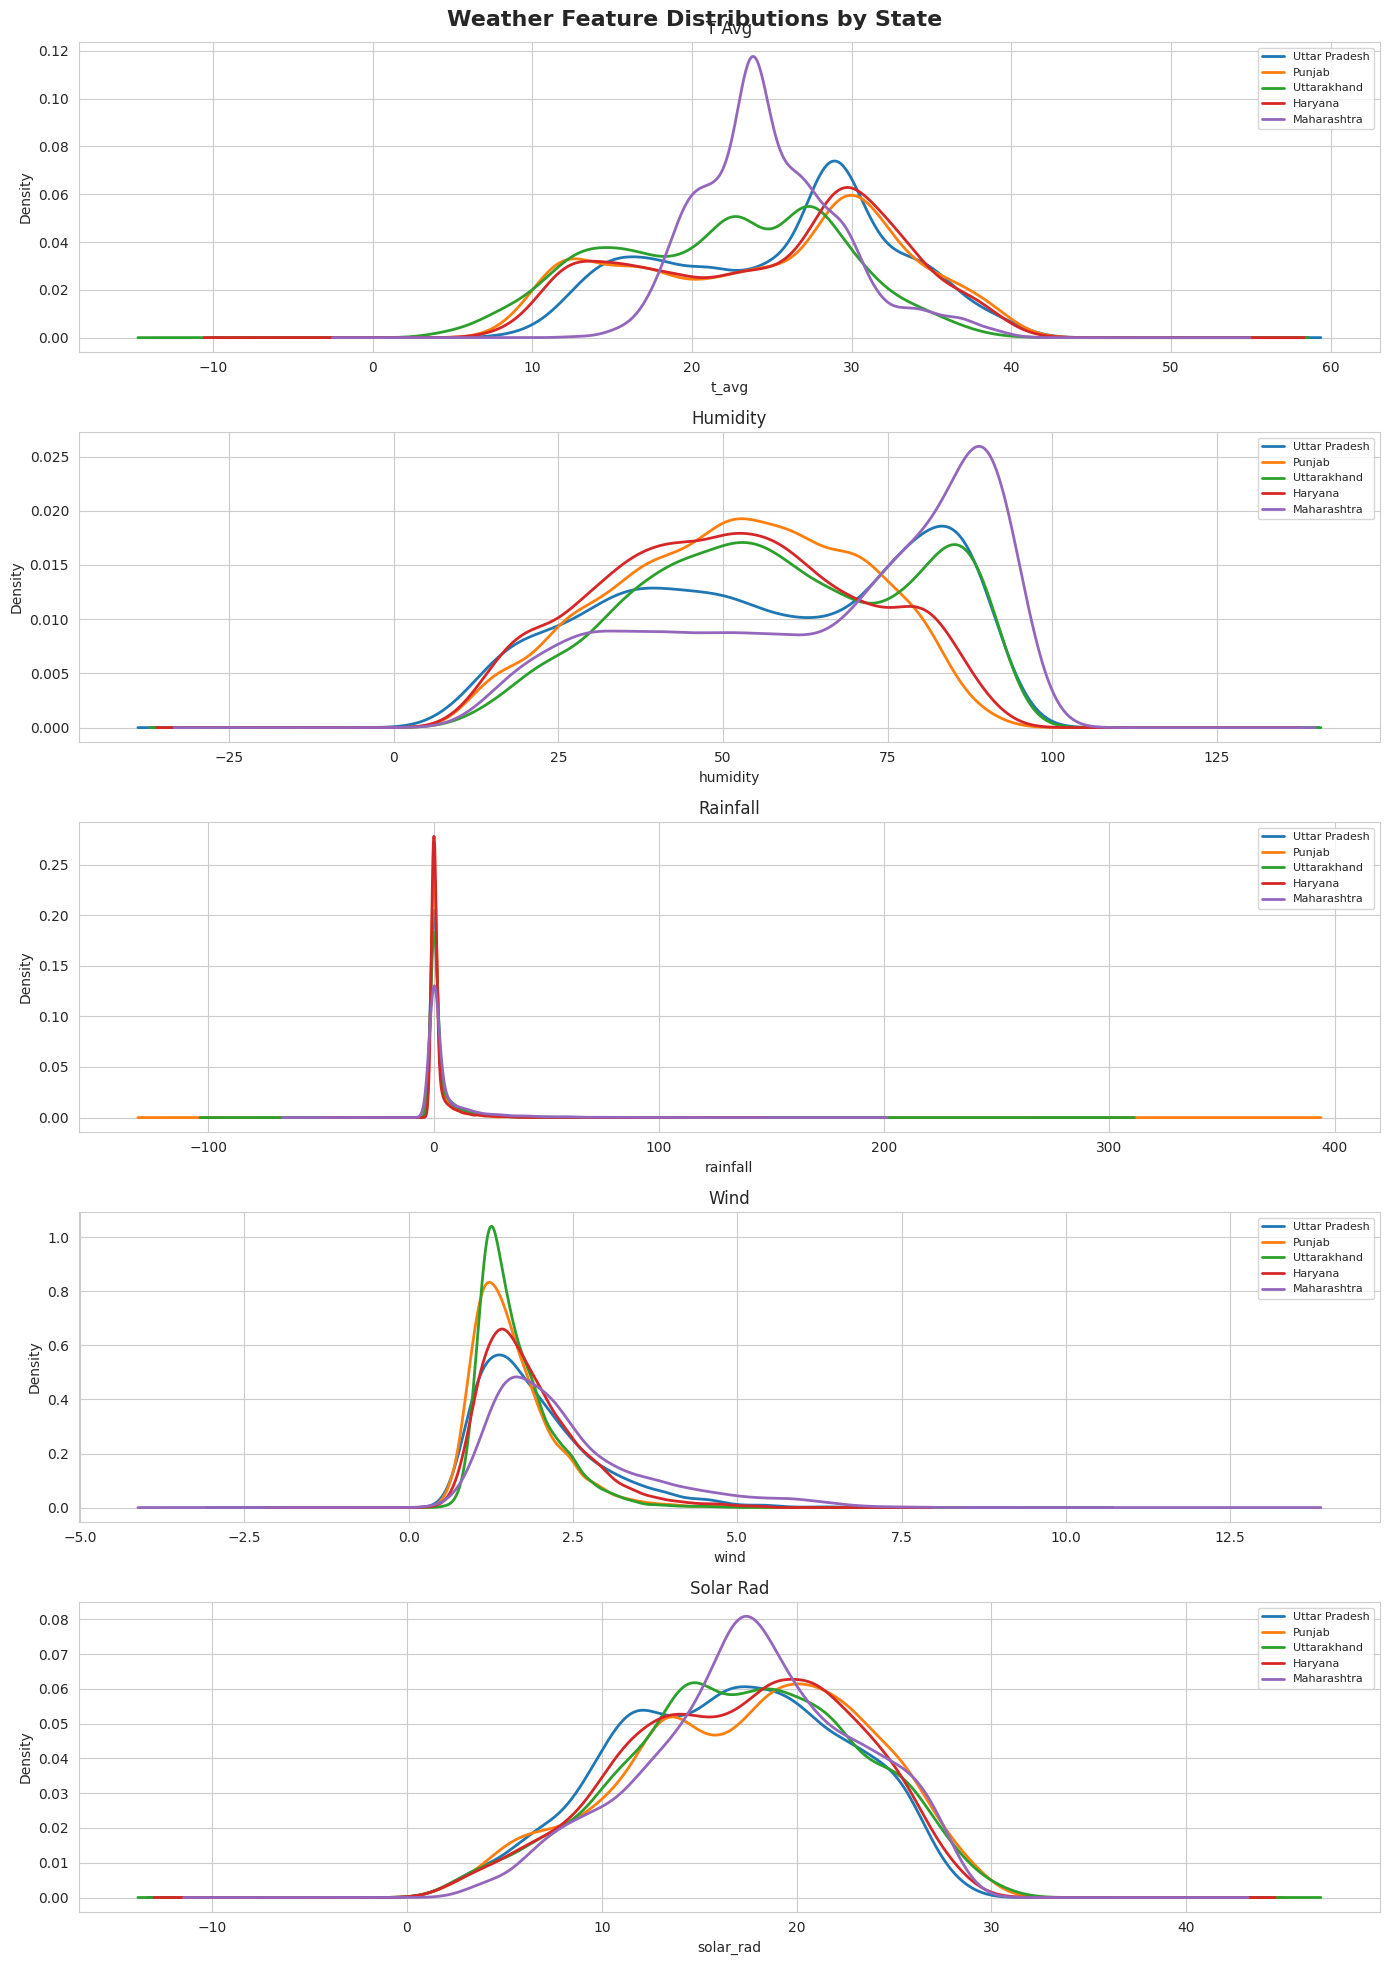

✅ Weather distribution plot saved.


In [ ]:
# ─── 6b. Weather Distribution per State ─────────────────────────────────────
weather_features = ['t_avg', 'humidity', 'rainfall', 'wind', 'solar_rad']

fig, axes = plt.subplots(len(weather_features), 1, figsize=(14, 4 * len(weather_features)))
fig.suptitle('Weather Feature Distributions by State', fontsize=16, fontweight='bold')

for ax, feat in zip(axes, weather_features):
    for state in master_df['state'].unique():
        subset = master_df[master_df['state'] == state][feat].dropna()
        subset.plot.kde(ax=ax, label=state, linewidth=2)
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend(fontsize=8)
    ax.set_xlabel(feat)

plt.tight_layout()
plt.savefig('/content/eda_weather_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Weather distribution plot saved.')

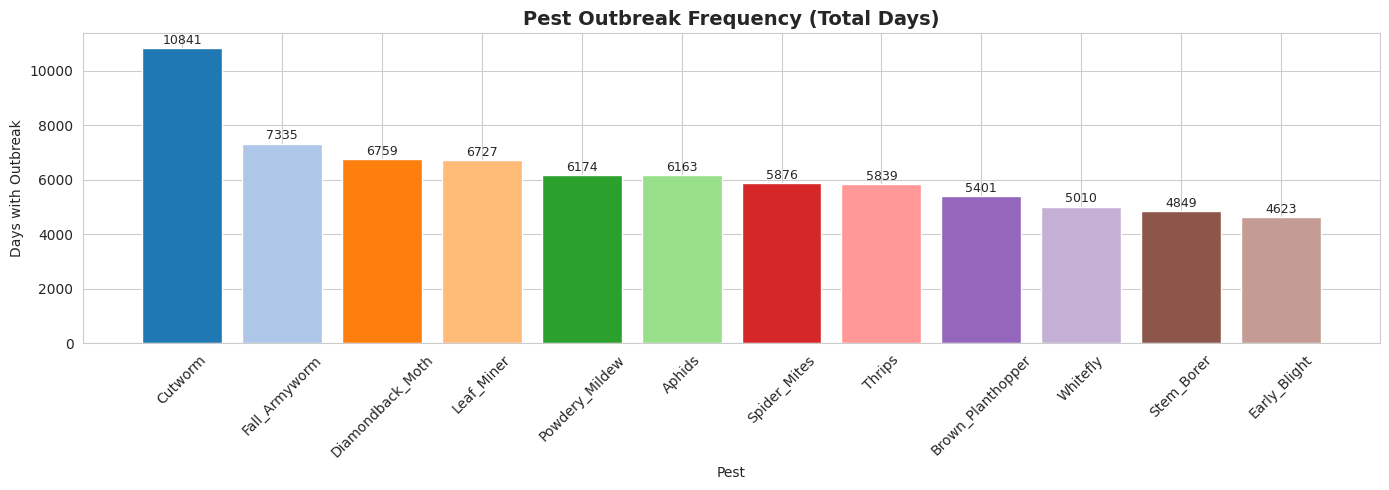

✅ Pest frequency chart saved.


In [ ]:
# ─── 6c. Pest Outbreak Frequency ─────────────────────────────────────────────
pest_freq = master_df[PEST_CLASSES].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(pest_freq.index, pest_freq.values,
              color=sns.color_palette('tab20', len(PEST_CLASSES)))
ax.set_title('Pest Outbreak Frequency (Total Days)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pest')
ax.set_ylabel('Days with Outbreak')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, pest_freq.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(int(val)), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/eda_pest_frequency.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Pest frequency chart saved.')

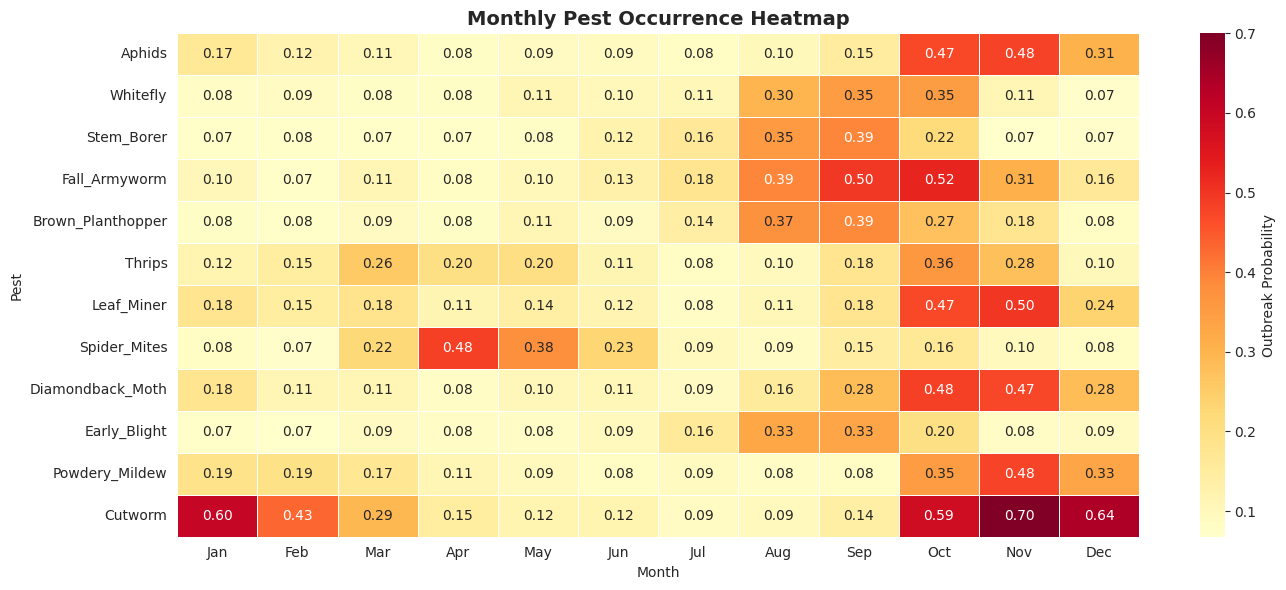

✅ Monthly heatmap saved.


In [ ]:
# ─── 6d. Monthly Pest Occurrence Heatmap ────────────────────────────────────
monthly = master_df.copy()
monthly['month_num'] = monthly['date'].dt.month
month_pest = monthly.groupby('month_num')[PEST_CLASSES].mean()
month_pest.index = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(month_pest.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Outbreak Probability'})
ax.set_title('Monthly Pest Occurrence Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Pest')
plt.tight_layout()
plt.savefig('/content/eda_monthly_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Monthly heatmap saved.')

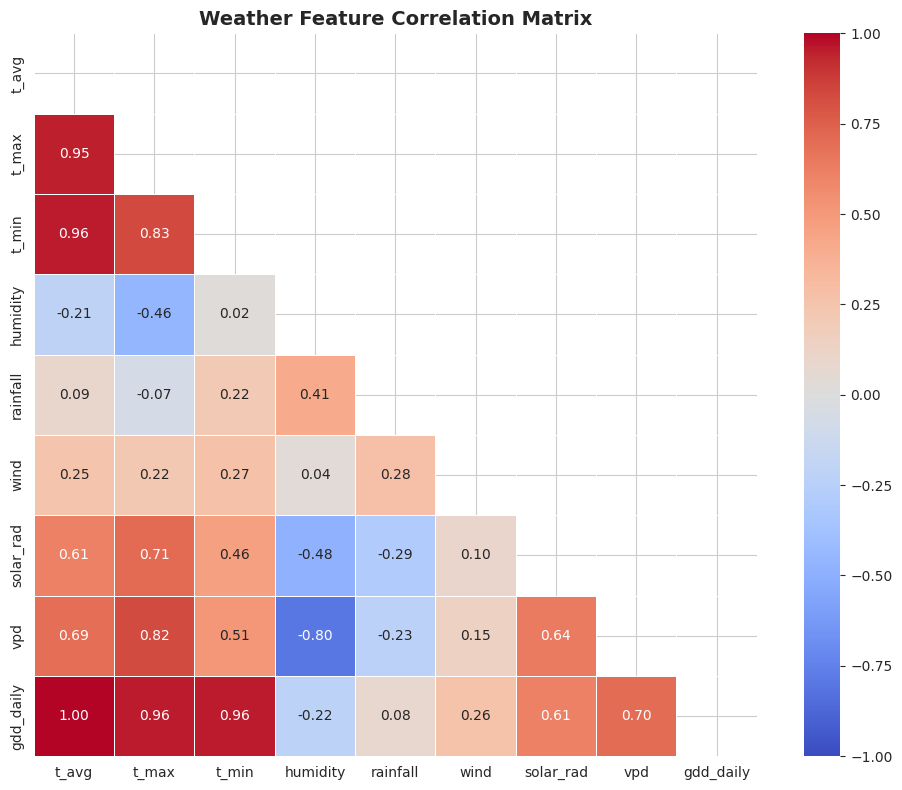

✅ Correlation matrix saved.


In [ ]:
# ─── 6e. Correlation Matrix of Weather Features ─────────────────────────────
corr_features = ['t_avg', 't_max', 't_min', 'humidity', 'rainfall',
                 'wind', 'solar_rad', 'vpd', 'gdd_daily']
corr_features = [c for c in corr_features if c in master_df.columns]
corr_matrix = master_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Weather Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/eda_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Correlation matrix saved.')

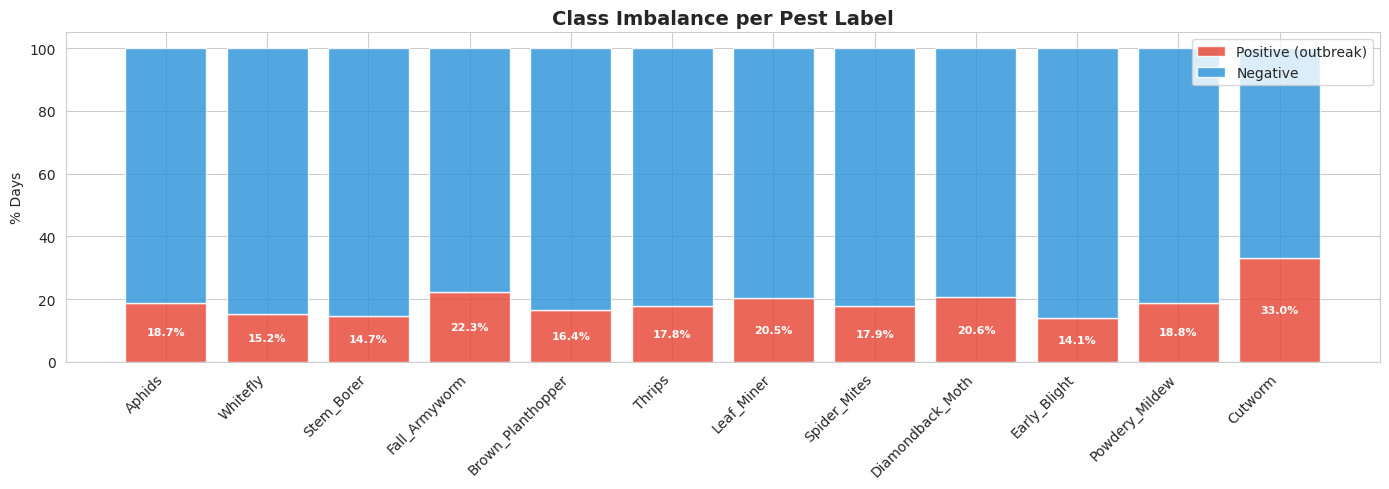

✅ Class imbalance chart saved.


In [ ]:
# ─── 6f. Class Imbalance Visualization ──────────────────────────────────────
pos_rate = master_df[PEST_CLASSES].mean() * 100
neg_rate = 100 - pos_rate

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(PEST_CLASSES))
ax.bar(x, pos_rate.values, label='Positive (outbreak)', color='#e74c3c', alpha=0.85)
ax.bar(x, neg_rate.values, bottom=pos_rate.values, label='Negative', color='#3498db', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(PEST_CLASSES, rotation=45, ha='right')
ax.set_ylabel('% Days')
ax.set_title('Class Imbalance per Pest Label', fontsize=14, fontweight='bold')
ax.legend()
for i, (p, n) in enumerate(zip(pos_rate.values, neg_rate.values)):
    ax.text(i, p/2, f'{p:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/eda_class_imbalance.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Class imbalance chart saved.')

## 7. Feature Selection

Steps:
1. Remove low-variance features
2. Remove highly correlated features (threshold > 0.92)
3. Mutual Information scores
4. Random Forest importance
5. Combine rankings → top 25 features

In [ ]:
# ─── Define candidate features ───────────────────────────────────────────────
EXCLUDE_COLS = PEST_CLASSES + ['date', 'district', 'state', 'season',
                                'month', 'doy', 'in_pest_temp_band',
                                'high_humidity_flag', 't_avg_7d', 'rh_7d', 'rain_7d']

candidate_features = [c for c in master_df.columns if c not in EXCLUDE_COLS
                      and master_df[c].dtype in [np.float64, np.float32, np.int64, np.int32, np.uint8, bool]
                      and master_df[c].notna().sum() > 100]

# Cast bool columns
for c in candidate_features:
    if master_df[c].dtype == bool:
        master_df[c] = master_df[c].astype(int)

print(f'Candidate features before selection: {len(candidate_features)}')

feat_df = master_df[candidate_features].copy().fillna(0)

# ─── Step 1: Low Variance Removal ────────────────────────────────────────────
sel_var = VarianceThreshold(threshold=0.01)
sel_var.fit(feat_df)
high_var_features = [c for c, keep in zip(candidate_features, sel_var.get_support()) if keep]
print(f'After low-variance removal: {len(high_var_features)} features')

# ─── Step 2: High Correlation Removal ────────────────────────────────────────
feat_corr = master_df[high_var_features].corr().abs()
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.92)]
uncorr_features = [f for f in high_var_features if f not in to_drop]
print(f'After high-correlation removal (>0.92): {len(uncorr_features)} features')

Candidate features before selection: 41
After low-variance removal: 41 features
After high-correlation removal (>0.92): 24 features


In [ ]:
# ─── Step 3: Mutual Information ───────────────────────────────────────────────
print('Computing Mutual Information scores (averaged across all pest labels)...')
X_sel = master_df[uncorr_features].fillna(0).values
Y_sel = master_df[PEST_CLASSES].values

mi_scores = np.zeros(len(uncorr_features))
for i, pest_col in enumerate(tqdm(PEST_CLASSES, desc='MI per pest')):
    y = Y_sel[:, i]
    if y.sum() < 10:
        continue
    mi = mutual_info_classif(X_sel, y, random_state=RANDOM_STATE, n_jobs=-1)
    mi_scores += mi

mi_scores /= len(PEST_CLASSES)
mi_series = pd.Series(mi_scores, index=uncorr_features).sort_values(ascending=False)
print('Top 10 by MI:', mi_series.head(10).index.tolist())

Computing Mutual Information scores (averaged across all pest labels)...


MI per pest:   0%|          | 0/12 [00:00<?, ?it/s]

Top 10 by MI: ['humidity', 't_avg', 'rain_cum7', 'rain_cum14', 'vpd', 'high_humidity_days7', 'month_cos', 'month_sin', 'pest_temp_days7', 'rain_cum3']


In [ ]:
# ─── Step 4: Random Forest Feature Importance ────────────────────────────────
print('Training quick Random Forest for feature importances...')
# Use first pest label as proxy (Aphids)
sample_idx = np.random.choice(len(X_sel), min(20000, len(X_sel)), replace=False)
X_sample = X_sel[sample_idx]
y_sample = Y_sel[sample_idx, 0]  # Aphids

rf_quick = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
rf_quick.fit(X_sample, y_sample)

rf_importance = pd.Series(rf_quick.feature_importances_, index=uncorr_features).sort_values(ascending=False)
print('Top 10 by RF importance:', rf_importance.head(10).index.tolist())

Training quick Random Forest for feature importances...
Top 10 by RF importance: ['t_avg', 'rain_cum7', 'humidity', 'vpd', 'high_humidity_days7', 'solar_rad', 'rain_cum3', 'rain_cum14', 'wind', 'month_cos']


In [ ]:
# ─── Step 5: Combined Ranking → Top 25 Features ──────────────────────────────
mi_rank = mi_series.rank(ascending=False)
rf_rank = rf_importance.rank(ascending=False)

combined_rank = (mi_rank + rf_rank).sort_values()
TOP_N = 25
selected_features = combined_rank.head(TOP_N).index.tolist()

print(f'\n✅ Top {TOP_N} selected features:')
for i, feat in enumerate(selected_features, 1):
    print(f'  {i:2d}. {feat}')


✅ Top 25 selected features:
   1. t_avg
   2. humidity
   3. rain_cum7
   4. vpd
   5. high_humidity_days7
   6. rain_cum14
   7. rain_cum3
   8. solar_rad
   9. month_cos
  10. month_sin
  11. rainfall
  12. pest_temp_days7
  13. wind
  14. rainfall_lag14
  15. rainfall_lag7
  16. is_kharif
  17. is_rabi
  18. state_Maharashtra
  19. year
  20. state_Haryana
  21. season_Zaid
  22. state_Punjab
  23. state_Uttarakhand
  24. state_Uttar Pradesh


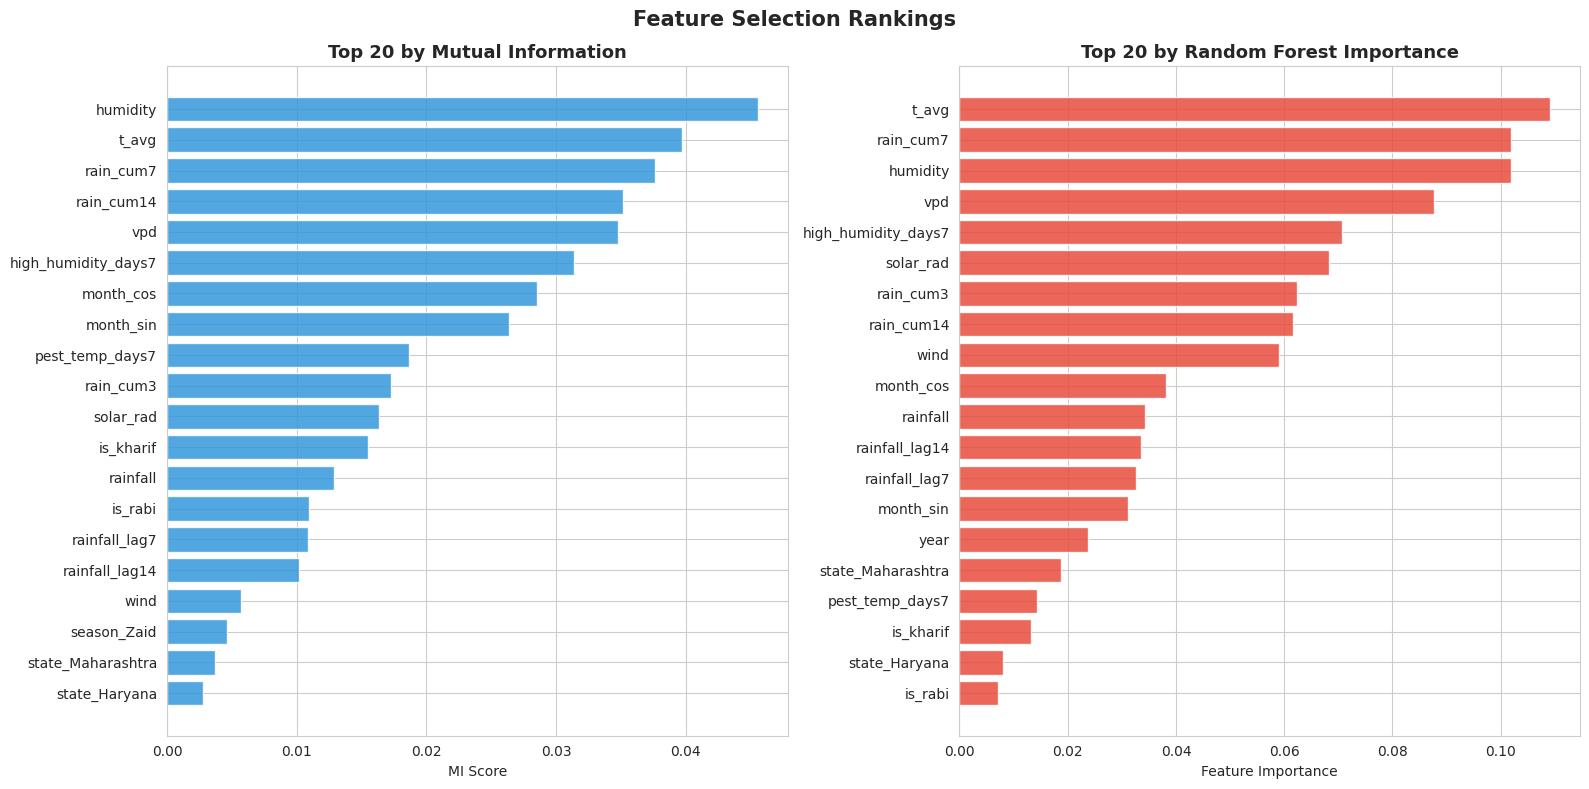

✅ Feature selection plot saved.


In [ ]:
# ─── Plot Top 20 Features: MI vs RF Side by Side ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

top20_mi = mi_series.head(20)
ax1.barh(top20_mi.index[::-1], top20_mi.values[::-1], color='#3498db', alpha=0.85)
ax1.set_title('Top 20 by Mutual Information', fontsize=13, fontweight='bold')
ax1.set_xlabel('MI Score')

top20_rf = rf_importance.head(20)
ax2.barh(top20_rf.index[::-1], top20_rf.values[::-1], color='#e74c3c', alpha=0.85)
ax2.set_title('Top 20 by Random Forest Importance', fontsize=13, fontweight='bold')
ax2.set_xlabel('Feature Importance')

plt.suptitle('Feature Selection Rankings', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/feature_selection.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Feature selection plot saved.')

## 8. Train / Validation / Test Split

**Time-based split only** (no random shuffle — this is temporal data):
- Train: 2019–2022
- Validation: 2023
- Test: 2024

In [ ]:
# Prepare X and Y
df_model = master_df[['date'] + selected_features + PEST_CLASSES].copy()
df_model = df_model.dropna(subset=selected_features)
df_model = df_model.sort_values('date')

# Fill any remaining NaNs in features
df_model[selected_features] = df_model[selected_features].fillna(df_model[selected_features].median())

X = df_model[selected_features].values.astype(np.float32)
Y = df_model[PEST_CLASSES].values.astype(np.int32)
dates = df_model['date'].values

# ─── Time-Based Split ─────────────────────────────────────────────────────────
train_mask = df_model['date'].dt.year <= 2022
val_mask   = df_model['date'].dt.year == 2023
test_mask  = df_model['date'].dt.year == 2024

X_train, Y_train = X[train_mask], Y[train_mask]
X_val,   Y_val   = X[val_mask],   Y[val_mask]
X_test,  Y_test  = X[test_mask],  Y[test_mask]

# ─── Scale Features ──────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Combined train+val for final retraining
X_trainval_s = np.vstack([X_train_s, X_val_s])
Y_trainval   = np.vstack([Y_train, Y_val])

print('✅ Train/Val/Test Split:')
print(f'   Train (2019-2022): X={X_train_s.shape}, Y={Y_train.shape}')
print(f'   Val   (2023):      X={X_val_s.shape},   Y={Y_val.shape}')
print(f'   Test  (2024):      X={X_test_s.shape},  Y={Y_test.shape}')
print(f'   Features: {len(selected_features)}')

✅ Train/Val/Test Split:
   Train (2019-2022): X=(21915, 24), Y=(21915, 12)
   Val   (2023):      X=(5475, 24),   Y=(5475, 12)
   Test  (2024):      X=(5490, 24),  Y=(5490, 12)
   Features: 24


## 9. Model Training & Hyperparameter Tuning

Three models with MultiOutputClassifier and RandomizedSearchCV + TimeSeriesSplit:
1. XGBoost
2. Random Forest
3. LightGBM

In [ ]:
from sklearn.metrics import make_scorer

# ─── Custom Scorer for MultiOutput ───────────────────────────────────────────
def multi_f1_micro(estimator, X, y):
    """
    Custom scorer that handles 2D multi-output arrays correctly.
    """
    y_pred = estimator.predict(X)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    return f1_score(y, y_pred, average='micro', zero_division=0)

custom_scorer = make_scorer(multi_f1_micro, greater_is_better=True)

# TimeSeriesSplit for validation
tscv = TimeSeriesSplit(n_splits=3)

print('✅ Custom scorer and TimeSeriesSplit ready.')
print('   This section tunes 3 models — may take 15-30 min on Colab free tier.')

✅ Custom scorer and TimeSeriesSplit ready.
   This section tunes 3 models — may take 15-30 min on Colab free tier.


In [ ]:
# ─── 9a. XGBoost ─────────────────────────────────────────────────────────────
print('=== TUNING XGBOOST ===')

xgb_param_dist = {
    'estimator__n_estimators':    [100, 200, 300],
    'estimator__max_depth':       [3, 5, 7, 9],
    'estimator__learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'estimator__subsample':       [0.6, 0.8, 1.0],
    'estimator__colsample_bytree':[0.6, 0.8, 1.0],
    'estimator__min_child_weight':[1, 3, 5],
}

xgb_base = MultiOutputClassifier(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    n_jobs=1
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist,
    n_iter=5, cv=tscv,
    scoring=custom_scorer,
    random_state=RANDOM_STATE,
    n_jobs=1, verbose=1, refit=True
)

xgb_search.fit(X_train_s, Y_train)
print(f'✅ XGBoost best CV F1-micro: {xgb_search.best_score_:.4f}')
print(f'   Best params: {xgb_search.best_params_}')

# Retrain on train+val
best_xgb = xgb_search.best_estimator_
best_xgb.fit(X_trainval_s, Y_trainval)
val_pred_xgb = xgb_search.best_estimator_.predict(X_val_s)
val_f1_xgb = f1_score(Y_val, val_pred_xgb, average='micro', zero_division=0)
print(f'   Validation F1-micro (before retrain): {val_f1_xgb:.4f}')

=== TUNING XGBOOST ===
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ XGBoost best CV F1-micro: nan
   Best params: {'estimator__subsample': 0.8, 'estimator__n_estimators': 100, 'estimator__min_child_weight': 5, 'estimator__max_depth': 5, 'estimator__learning_rate': 0.1, 'estimator__colsample_bytree': 1.0}
   Validation F1-micro (before retrain): 0.7183


In [ ]:
# ─── 9b. Random Forest ───────────────────────────────────────────────────────
print('=== TUNING RANDOM FOREST ===')

rf_param_dist = {
    'estimator__n_estimators':   [100, 200, 300],
    'estimator__max_depth':      [None, 10, 20, 30],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf':  [1, 2, 4],
    'estimator__max_features':   ['sqrt', 'log2', 0.5],
}

rf_base = MultiOutputClassifier(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    n_jobs=1
)

rf_search = RandomizedSearchCV(
    rf_base, rf_param_dist,
    n_iter=5, cv=tscv,
    scoring=custom_scorer,
    random_state=RANDOM_STATE,
    n_jobs=1, verbose=1, refit=True
)

rf_search.fit(X_train_s, Y_train)
print(f'✅ Random Forest best CV F1-micro: {rf_search.best_score_:.4f}')
print(f'   Best params: {rf_search.best_params_}')

best_rf = rf_search.best_estimator_
best_rf.fit(X_trainval_s, Y_trainval)
val_pred_rf = rf_search.best_estimator_.predict(X_val_s)
val_f1_rf = f1_score(Y_val, val_pred_rf, average='micro', zero_division=0)
print(f'   Validation F1-micro (before retrain): {val_f1_rf:.4f}')

=== TUNING RANDOM FOREST ===
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ Random Forest best CV F1-micro: nan
   Best params: {'estimator__n_estimators': 100, 'estimator__min_samples_split': 10, 'estimator__min_samples_leaf': 4, 'estimator__max_features': 'log2', 'estimator__max_depth': 10}
   Validation F1-micro (before retrain): 0.7181


In [ ]:
# ─── 9c. LightGBM ────────────────────────────────────────────────────────────
print('=== TUNING LIGHTGBM ===')

lgb_param_dist = {
    'estimator__n_estimators':      [100, 200, 300],
    'estimator__max_depth':         [3, 5, 7, -1],
    'estimator__learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'estimator__num_leaves':        [15, 31, 63, 127],
    'estimator__min_child_samples': [10, 20, 50],
    'estimator__subsample':         [0.6, 0.8, 1.0],
}

lgb_base = MultiOutputClassifier(
    lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    n_jobs=1
)

lgb_search = RandomizedSearchCV(
    lgb_base, lgb_param_dist,
    n_iter=5, cv=tscv,
    scoring=custom_scorer,
    random_state=RANDOM_STATE,
    n_jobs=1, verbose=1, refit=True
)

lgb_search.fit(X_train_s, Y_train)
print(f'✅ LightGBM best CV F1-micro: {lgb_search.best_score_:.4f}')
print(f'   Best params: {lgb_search.best_params_}')

best_lgb = lgb_search.best_estimator_
best_lgb.fit(X_trainval_s, Y_trainval)
val_pred_lgb = lgb_search.best_estimator_.predict(X_val_s)
val_f1_lgb = f1_score(Y_val, val_pred_lgb, average='micro', zero_division=0)
print(f'   Validation F1-micro (before retrain): {val_f1_lgb:.4f}')

=== TUNING LIGHTGBM ===
Fitting 3 folds for each of 5 candidates, totalling 15 fits
✅ LightGBM best CV F1-micro: nan
   Best params: {'estimator__subsample': 0.8, 'estimator__num_leaves': 127, 'estimator__n_estimators': 100, 'estimator__min_child_samples': 20, 'estimator__max_depth': 7, 'estimator__learning_rate': 0.1}
   Validation F1-micro (before retrain): 0.7513


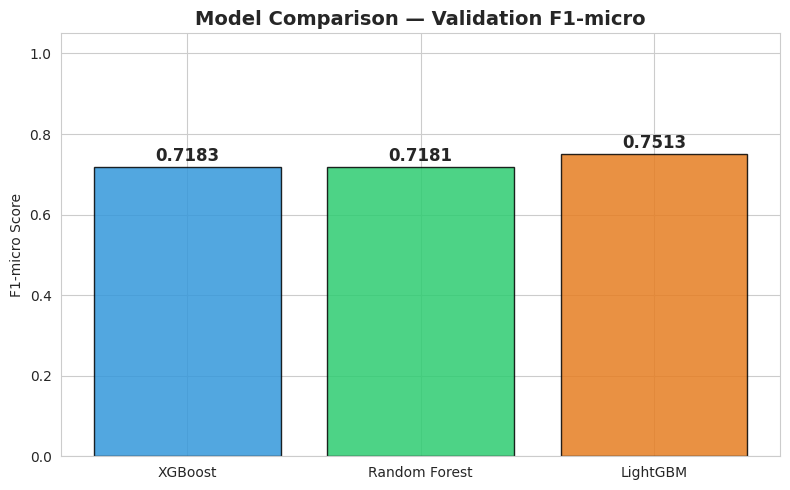


🏆 Best model: LightGBM (val F1-micro = 0.7513)


In [ ]:
# ─── Model Comparison Bar Chart (Validation F1-micro) ───────────────────────
model_names = ['XGBoost', 'Random Forest', 'LightGBM']
val_f1_scores = [val_f1_xgb, val_f1_rf, val_f1_lgb]
colors = ['#3498db', '#2ecc71', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, val_f1_scores, color=colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, val_f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison — Validation F1-micro', fontsize=14, fontweight='bold')
ax.set_ylabel('F1-micro Score')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# Determine best model
best_val_idx  = np.argmax(val_f1_scores)
best_model_name = model_names[best_val_idx]
best_model = [best_xgb, best_rf, best_lgb][best_val_idx]
print(f'\n🏆 Best model: {best_model_name} (val F1-micro = {val_f1_scores[best_val_idx]:.4f})')

## 10. Evaluation on Test Set

Computes all required metrics for all 3 models and visualises per-class performance.

In [ ]:
def evaluate_model(model, X_test, Y_test, model_name='Model'):
    """
    Comprehensive evaluation for multi-label classification.
    Returns metrics dict.
    """
    Y_pred = model.predict(X_test)

    # Try getting probabilities
    try:
        Y_prob = np.array([est.predict_proba(X_test)[:, 1]
                           for est in model.estimators_]).T
    except Exception:
        Y_prob = Y_pred.astype(float)

    metrics = {}
    metrics['model']           = model_name
    metrics['hamming_loss']    = hamming_loss(Y_test, Y_pred)
    metrics['subset_accuracy'] = accuracy_score(Y_test, Y_pred)
    metrics['f1_micro']        = f1_score(Y_test, Y_pred, average='micro',     zero_division=0)
    metrics['f1_macro']        = f1_score(Y_test, Y_pred, average='macro',     zero_division=0)
    metrics['f1_weighted']     = f1_score(Y_test, Y_pred, average='weighted',  zero_division=0)
    metrics['jaccard']         = jaccard_score(Y_test, Y_pred, average='micro', zero_division=0)

    # ROC-AUC — handle classes with only one label
    try:
        valid_cls = [i for i in range(Y_test.shape[1])
                     if len(np.unique(Y_test[:, i])) > 1]
        if len(valid_cls) > 0:
            metrics['roc_auc_macro'] = roc_auc_score(
                Y_test[:, valid_cls], Y_prob[:, valid_cls], average='macro')
            metrics['roc_auc_micro'] = roc_auc_score(
                Y_test[:, valid_cls], Y_prob[:, valid_cls], average='micro')
        else:
            metrics['roc_auc_macro'] = np.nan
            metrics['roc_auc_micro'] = np.nan
    except Exception as e:
        metrics['roc_auc_macro'] = np.nan
        metrics['roc_auc_micro'] = np.nan
        print(f'    ROC-AUC error: {e}')

    # Per-class metrics
    per_class = []
    for i, pest in enumerate(PEST_CLASSES):
        per_class.append({
            'pest':      pest,
            'f1':        f1_score(Y_test[:, i], Y_pred[:, i], zero_division=0),
            'precision': precision_score(Y_test[:, i], Y_pred[:, i], zero_division=0),
            'recall':    recall_score(Y_test[:, i], Y_pred[:, i], zero_division=0),
        })
    metrics['per_class_df'] = pd.DataFrame(per_class)
    metrics['Y_pred']       = Y_pred
    metrics['Y_prob']       = Y_prob

    return metrics


print('Evaluating all 3 models on Test Set (2024)...')
eval_xgb = evaluate_model(best_xgb, X_test_s, Y_test, 'XGBoost')
eval_rf  = evaluate_model(best_rf,  X_test_s, Y_test, 'Random Forest')
eval_lgb = evaluate_model(best_lgb, X_test_s, Y_test, 'LightGBM')

all_evals = [eval_xgb, eval_rf, eval_lgb]

# ─── Summary Table ────────────────────────────────────────────────────────────
summary_rows = []
for ev in all_evals:
    summary_rows.append({
        'Model':           ev['model'],
        'Hamming Loss':    round(ev['hamming_loss'],    4),
        'Subset Accuracy': round(ev['subset_accuracy'], 4),
        'F1-micro':        round(ev['f1_micro'],        4),
        'F1-macro':        round(ev['f1_macro'],        4),
        'F1-weighted':     round(ev['f1_weighted'],     4),
        'ROC-AUC macro':   round(ev['roc_auc_macro'],   4) if not np.isnan(ev['roc_auc_macro']) else 'N/A',
        'ROC-AUC micro':   round(ev['roc_auc_micro'],   4) if not np.isnan(ev['roc_auc_micro']) else 'N/A',
        'Jaccard':         round(ev['jaccard'],         4),
    })

summary_df = pd.DataFrame(summary_rows)
print('\n=== TEST SET EVALUATION SUMMARY ===')
print(summary_df.to_string(index=False))

Evaluating all 3 models on Test Set (2024)...

=== TEST SET EVALUATION SUMMARY ===
        Model  Hamming Loss  Subset Accuracy  F1-micro  F1-macro  F1-weighted  ROC-AUC macro  ROC-AUC micro  Jaccard
      XGBoost        0.1115           0.2543    0.6579    0.6447       0.6540         0.7929         0.8007   0.4902
Random Forest        0.1114           0.2583    0.6522    0.6365       0.6460         0.7936         0.8015   0.4839
     LightGBM        0.1126           0.2468    0.6538    0.6407       0.6498         0.7914         0.7988   0.4856


In [ ]:
# ─── Per-Class F1 Score Display ───────────────────────────────────────────────
print('\n=== PER-CLASS METRICS (Best Model: ' + best_model_name + ') ===')
best_eval = [ev for ev in all_evals if ev['model'] == best_model_name][0]
print(best_eval['per_class_df'].to_string(index=False))


=== PER-CLASS METRICS (Best Model: LightGBM) ===
             pest       f1  precision   recall
           Aphids 0.695954   0.844320 0.591937
         Whitefly 0.516432   0.648148 0.429208
       Stem_Borer 0.664675   0.902637 0.526005
    Fall_Armyworm 0.735632   0.861953 0.641604
Brown_Planthopper 0.553629   0.820952 0.417636
           Thrips 0.527154   0.738337 0.409910
       Leaf_Miner 0.665977   0.754098 0.596296
     Spider_Mites 0.609307   0.797450 0.492995
 Diamondback_Moth 0.733899   0.887681 0.625532
     Early_Blight 0.628331   0.851711 0.497778
   Powdery_Mildew 0.605471   0.729136 0.517672
          Cutworm 0.751340   0.782275 0.722760


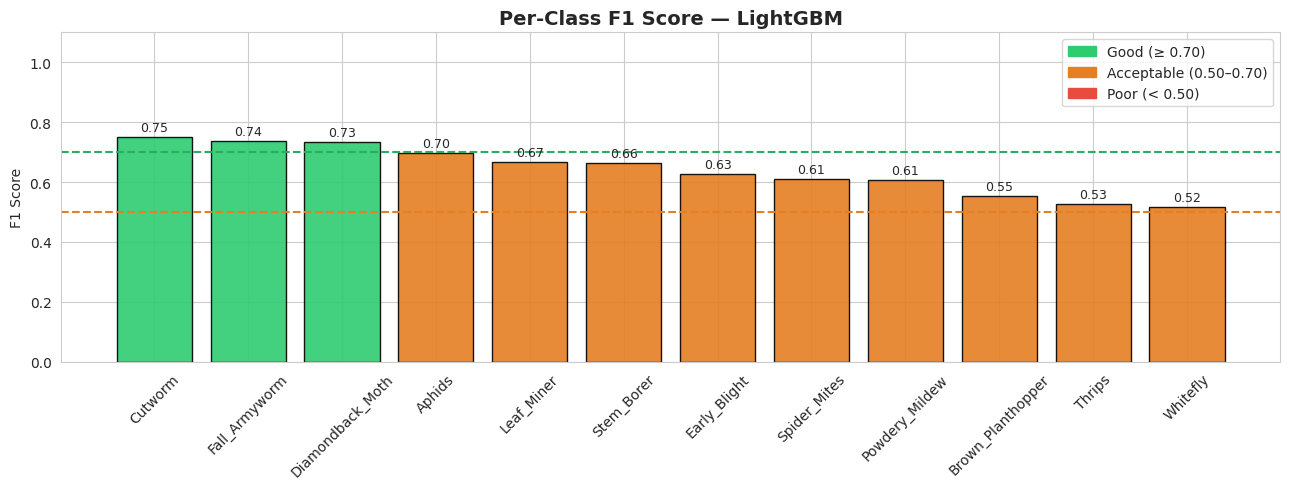

✅ Per-class F1 chart saved.


In [ ]:
# ─── Per-Class F1 Bar Chart (Color-coded by tier) ────────────────────────────
pc_df = best_eval['per_class_df'].sort_values('f1', ascending=False)

def f1_color(val):
    if val >= 0.7: return '#2ecc71'   # green
    elif val >= 0.5: return '#e67e22' # orange
    else: return '#e74c3c'            # red

bar_colors = [f1_color(v) for v in pc_df['f1'].values]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(pc_df['pest'], pc_df['f1'], color=bar_colors, edgecolor='black', alpha=0.9)
for bar, val in zip(bars, pc_df['f1'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0.7, color='#27ae60', linestyle='--', linewidth=1.5, label='Good (>0.7)')
ax.axhline(0.5, color='#e67e22', linestyle='--', linewidth=1.5, label='Acceptable (>0.5)')
ax.set_title(f'Per-Class F1 Score — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=45)

patches = [
    mpatches.Patch(color='#2ecc71', label='Good (≥ 0.70)'),
    mpatches.Patch(color='#e67e22', label='Acceptable (0.50–0.70)'),
    mpatches.Patch(color='#e74c3c', label='Poor (< 0.50)'),
]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.savefig('/content/per_class_f1.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Per-class F1 chart saved.')

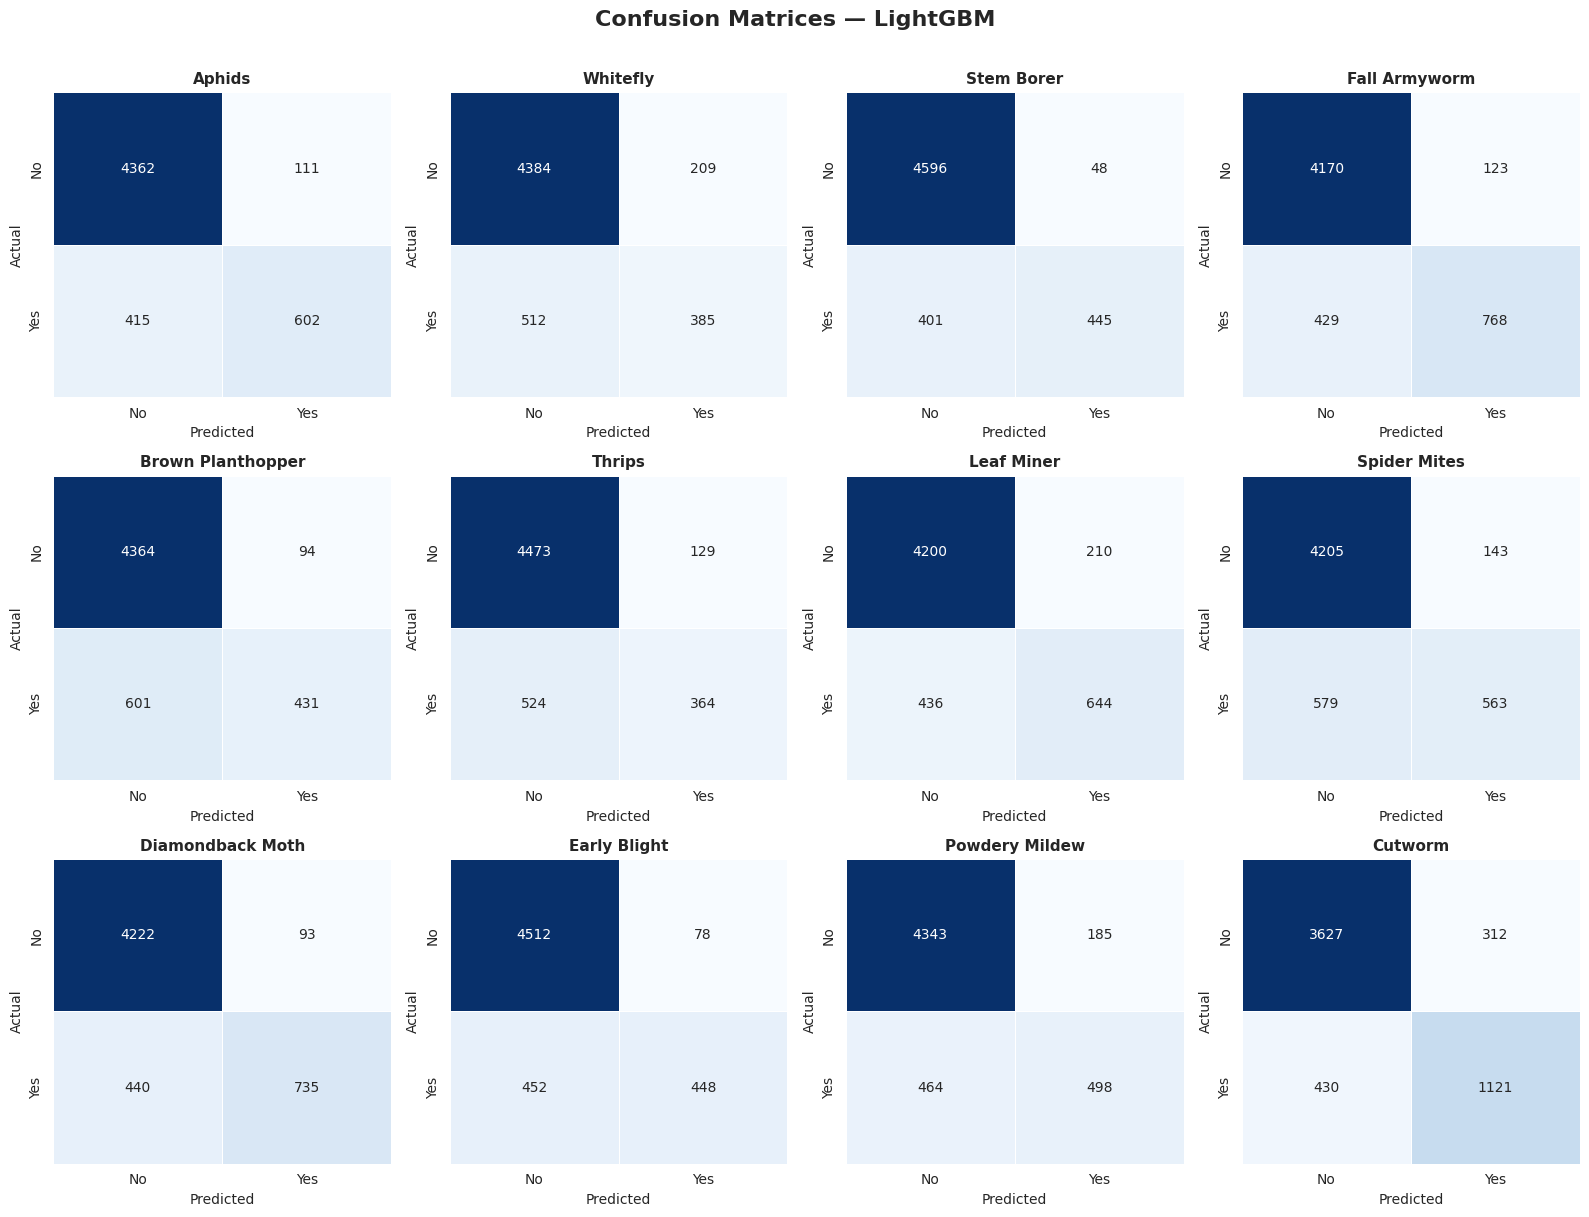

✅ Confusion matrix grid saved.


In [ ]:
# ─── Confusion Matrix Grid (all 12 pest classes) ─────────────────────────────
Y_pred_best = best_eval['Y_pred']

n_cols = 4
n_rows = math.ceil(len(PEST_CLASSES) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, pest in enumerate(PEST_CLASSES):
    cm = confusion_matrix(Y_test[:, i], Y_pred_best[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                cbar=False, linewidths=0.5)
    axes[i].set_title(pest.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Confusion Matrices — {best_model_name}', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix grid saved.')

## 11. Save Artifacts

Saves all required files for backend engineers:
1. `pest_model.pkl`
2. `pest_scaler.pkl`
3. `pest_feature_names.pkl`
4. `pest_classes.pkl`
5. `crop_pest_mapping.pkl`
6. `pest_model_metadata.json`
7. `all_models.pkl`

In [ ]:
ARTIFACT_DIR = '/content/pest_model_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 1. Best model
joblib.dump(best_model, os.path.join(ARTIFACT_DIR, 'pest_model.pkl'))
print('✅ Saved pest_model.pkl')

# 2. Scaler
joblib.dump(scaler, os.path.join(ARTIFACT_DIR, 'pest_scaler.pkl'))
print('✅ Saved pest_scaler.pkl')

# 3. Feature names
joblib.dump(selected_features, os.path.join(ARTIFACT_DIR, 'pest_feature_names.pkl'))
print('✅ Saved pest_feature_names.pkl')

# 4. Pest classes
joblib.dump(PEST_CLASSES, os.path.join(ARTIFACT_DIR, 'pest_classes.pkl'))
print('✅ Saved pest_classes.pkl')

# 5. Crop-pest mapping
joblib.dump(CROP_PEST_MAPPING, os.path.join(ARTIFACT_DIR, 'crop_pest_mapping.pkl'))
print('✅ Saved crop_pest_mapping.pkl')

# 6. Metadata JSON
best_test_eval = [ev for ev in all_evals if ev['model'] == best_model_name][0]
metadata = {
    'model_name':        best_model_name,
    'training_date_range': f'{START_DATE} to 2022-12-31',
    'test_date_range':   '2024-01-01 to 2024-12-31',
    'test_f1_micro':     round(best_test_eval['f1_micro'],    4),
    'test_hamming_loss': round(best_test_eval['hamming_loss'], 4),
    'test_roc_auc':      round(best_test_eval['roc_auc_macro'], 4)
                         if not np.isnan(best_test_eval['roc_auc_macro']) else None,
    'states_covered':    list(DISTRICTS.keys()),
    'crops_covered':     list(CROP_PEST_MAPPING.keys()),
    'forecast_window_days': 7,
    'feature_count':     len(selected_features),
    'class_count':       len(PEST_CLASSES),
    'pest_classes':      PEST_CLASSES,
    'created_at':        datetime.now().isoformat(),
}

with open(os.path.join(ARTIFACT_DIR, 'pest_model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅ Saved pest_model_metadata.json')
print(json.dumps(metadata, indent=2))

# 7. All models together
all_models_dict = {
    'XGBoost':       best_xgb,
    'Random Forest': best_rf,
    'LightGBM':      best_lgb,
    'best_model_name': best_model_name,
}
joblib.dump(all_models_dict, os.path.join(ARTIFACT_DIR, 'all_models.pkl'))
print('✅ Saved all_models.pkl')

print(f'\n📦 All artifacts saved to: {ARTIFACT_DIR}')
print('   Files:')
for f in os.listdir(ARTIFACT_DIR):
    size = os.path.getsize(os.path.join(ARTIFACT_DIR, f)) / 1024
    print(f'   • {f:<35} {size:.1f} KB')

✅ Saved pest_model.pkl
✅ Saved pest_scaler.pkl
✅ Saved pest_feature_names.pkl
✅ Saved pest_classes.pkl
✅ Saved crop_pest_mapping.pkl
✅ Saved pest_model_metadata.json
{
  "model_name": "LightGBM",
  "training_date_range": "2019-01-01 to 2022-12-31",
  "test_date_range": "2024-01-01 to 2024-12-31",
  "test_f1_micro": 0.6538,
  "test_hamming_loss": 0.1126,
  "test_roc_auc": 0.7914,
  "states_covered": [
    "Punjab",
    "Haryana",
    "Uttar Pradesh",
    "Maharashtra",
    "Uttarakhand"
  ],
  "crops_covered": [
    "Rice",
    "Wheat",
    "Maize",
    "Tomato",
    "Potato",
    "Onion",
    "Cotton",
    "Sugarcane",
    "Chickpea",
    "Sweetcorn",
    "Garlic",
    "Carrot",
    "Capsicum",
    "Cabbage"
  ],
  "forecast_window_days": 7,
  "feature_count": 24,
  "class_count": 12,
  "pest_classes": [
    "Aphids",
    "Whitefly",
    "Stem_Borer",
    "Fall_Armyworm",
    "Brown_Planthopper",
    "Thrips",
    "Leaf_Miner",
    "Spider_Mites",
    "Diamondback_Moth",
    "Early_Bli

## 12. Inference Function

`predict_pest_risk(weather_7day_forecast, crop_type, state)` — takes 7 days of daily weather forecast data, the crop type, and state, and returns a dictionary of per-pest outbreak probability and risk level, filtered to pests relevant to that crop.

In [ ]:
# ─── Load saved artifacts (so inference works independently) ─────────────────
_model     = joblib.load(os.path.join(ARTIFACT_DIR, 'pest_model.pkl'))
_scaler    = joblib.load(os.path.join(ARTIFACT_DIR, 'pest_scaler.pkl'))
_feat_names= joblib.load(os.path.join(ARTIFACT_DIR, 'pest_feature_names.pkl'))
_classes   = joblib.load(os.path.join(ARTIFACT_DIR, 'pest_classes.pkl'))
_crop_map  = joblib.load(os.path.join(ARTIFACT_DIR, 'crop_pest_mapping.pkl'))

print('✅ Artifacts loaded for inference.')
print(f'   Model: {type(_model).__name__}')
print(f'   Features expected: {len(_feat_names)}')
print(f'   Pest classes: {_classes}')

✅ Artifacts loaded for inference.
   Model: MultiOutputClassifier
   Features expected: 24
   Pest classes: ['Aphids', 'Whitefly', 'Stem_Borer', 'Fall_Armyworm', 'Brown_Planthopper', 'Thrips', 'Leaf_Miner', 'Spider_Mites', 'Diamondback_Moth', 'Early_Blight', 'Powdery_Mildew', 'Cutworm']


In [ ]:
def _build_inference_features(weather_7day: list, crop_type: str, state: str) -> pd.DataFrame:
    """
    Build a single-row feature vector from 7 days of forecast weather.

    Parameters
    ----------
    weather_7day : list of 7 dicts, each with keys:
        t_avg, t_max, t_min, humidity, rainfall, wind
    crop_type : str — one of the 14 supported crops
    state     : str — one of the 5 supported states

    Returns
    -------
    pd.DataFrame with one row, all columns matching _feat_names
    """
    assert len(weather_7day) == 7, 'weather_7day must be a list of exactly 7 dicts'

    df = pd.DataFrame(weather_7day)
    df['date'] = pd.date_range(end=pd.Timestamp.today(), periods=7, freq='D')

    # Basic derived fields
    df['solar_rad'] = 15.0  # approximate if not provided
    df['gdd_daily'] = ((df['t_max'] + df['t_min']) / 2 - 10).clip(lower=0)
    df['vpd'] = (0.6108 * np.exp(17.27 * df['t_avg'] / (df['t_avg'] + 237.3))
                 * (1 - df['humidity'] / 100)).clip(lower=0)

    df['in_pest_temp_band'] = ((df['t_avg'] >= 25) & (df['t_avg'] <= 35)).astype(int)
    df['high_humidity_flag'] = (df['humidity'] > 70).astype(int)

    # Rolling features (over the 7-day window)
    for window in [7, 14, 30]:
        df[f't_avg_roll{window}']   = df['t_avg'].rolling(min(window, 7), min_periods=1).mean()
        df[f'humidity_roll{window}'] = df['humidity'].rolling(min(window, 7), min_periods=1).mean()

    for window in [3, 7, 14]:
        df[f'rain_cum{window}'] = df['rainfall'].rolling(min(window, 7), min_periods=1).sum()

    df['gdd_cum30']         = df['gdd_daily'].rolling(7, min_periods=1).sum()
    df['pest_temp_days7']   = df['in_pest_temp_band'].rolling(7, min_periods=1).sum()
    df['high_humidity_days7'] = df['high_humidity_flag'].rolling(7, min_periods=1).sum()

    # Lag features (use first available value as proxy)
    for lag in [7, 14]:
        df[f't_avg_lag{lag}']    = df['t_avg'].shift(lag).fillna(df['t_avg'].mean())
        df[f'humidity_lag{lag}'] = df['humidity'].shift(lag).fillna(df['humidity'].mean())
        df[f'rainfall_lag{lag}'] = df['rainfall'].shift(lag).fillna(df['rainfall'].mean())

    # Cyclical time
    df['month']     = df['date'].dt.month
    df['doy']       = df['date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['doy'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['doy'] / 365)

    # Season
    month = df['month'].iloc[-1]
    if 6 <= month <= 11:   season = 'Kharif'
    elif month in [12, 1, 2, 3, 4, 11]: season = 'Rabi'
    else: season = 'Zaid'

    df['is_kharif'] = int(season == 'Kharif')
    df['is_rabi']   = int(season == 'Rabi')
    df['season_Rabi']  = int(season == 'Rabi')
    df['season_Zaid']  = int(season == 'Zaid')

    df['year'] = df['date'].dt.year

    # State one-hot
    all_states = ['Punjab', 'Haryana', 'Uttar Pradesh', 'Maharashtra', 'Uttarakhand']
    for s in all_states:
        df[f'state_{s}'] = int(s == state)

    # Take the last row (day 7 = forecast target)
    row = df.iloc[[-1]].copy()

    # Align to expected features
    for feat in _feat_names:
        if feat not in row.columns:
            row[feat] = 0.0

    return row[_feat_names].fillna(0.0)


def predict_pest_risk(weather_7day_forecast: list, crop_type: str, state: str) -> dict:
    """
    Predict pest outbreak risk for the next 7 days.

    Parameters
    ----------
    weather_7day_forecast : list of 7 dicts with keys:
        t_avg, t_max, t_min, humidity, rainfall, wind
    crop_type : str — e.g. 'Rice', 'Wheat', 'Tomato'
    state     : str — e.g. 'Punjab', 'Maharashtra'

    Returns
    -------
    dict: {pest_name: {'probability': float, 'risk_level': 'HIGH'/'MEDIUM'/'LOW'}}
          Filtered to pests relevant to the given crop.
    """
    # Validate inputs
    if crop_type not in _crop_map:
        raise ValueError(f'Unknown crop: {crop_type}. Supported: {list(_crop_map.keys())}')
    if state not in list(DISTRICTS.keys()):
        raise ValueError(f'Unknown state: {state}. Supported: {list(DISTRICTS.keys())}')

    # Build feature row
    X_inf = _build_inference_features(weather_7day_forecast, crop_type, state)
    X_scaled = _scaler.transform(X_inf.values)

    # Get predictions and probabilities
    y_pred = _model.predict(X_scaled)[0]  # shape (n_classes,)
    try:
        y_prob = np.array([est.predict_proba(X_scaled)[0, 1]
                           for est in _model.estimators_])
    except Exception:
        y_prob = y_pred.astype(float)

    # Get relevant pests for this crop
    relevant_pests = _crop_map[crop_type]

    results = {}
    for i, pest in enumerate(_classes):
        if pest not in relevant_pests:
            continue
        prob = float(y_prob[i])
        if prob >= 0.65:   risk = 'HIGH'
        elif prob >= 0.40: risk = 'MEDIUM'
        else:              risk = 'LOW'

        results[pest] = {
            'probability': round(prob, 4),
            'risk_level':  risk,
        }

    # Sort by probability descending
    results = dict(sorted(results.items(), key=lambda x: x[1]['probability'], reverse=True))
    return results


print('✅ predict_pest_risk() function defined.')

✅ predict_pest_risk() function defined.


In [ ]:
# ─── Sample Inference Call ────────────────────────────────────────────────────
sample_forecast = [
    {'t_avg': 28.5, 't_max': 34.0, 't_min': 23.0, 'humidity': 75, 'rainfall': 2.1, 'wind': 3.2},
    {'t_avg': 29.0, 't_max': 35.0, 't_min': 23.5, 'humidity': 78, 'rainfall': 0.0, 'wind': 2.8},
    {'t_avg': 30.0, 't_max': 36.5, 't_min': 24.0, 'humidity': 80, 'rainfall': 0.0, 'wind': 2.5},
    {'t_avg': 31.0, 't_max': 37.0, 't_min': 25.0, 'humidity': 82, 'rainfall': 0.5, 'wind': 3.0},
    {'t_avg': 29.5, 't_max': 35.5, 't_min': 24.5, 'humidity': 79, 'rainfall': 1.2, 'wind': 3.5},
    {'t_avg': 28.0, 't_max': 34.0, 't_min': 22.5, 'humidity': 76, 'rainfall': 0.0, 'wind': 4.0},
    {'t_avg': 27.5, 't_max': 33.5, 't_min': 22.0, 'humidity': 74, 'rainfall': 3.5, 'wind': 3.8},
]

crop   = 'Tomato'
state  = 'Maharashtra'

print(f'🔍 Predicting pest risk for crop={crop}, state={state}')
print(f'   7-day forecast: avg temp {np.mean([d["t_avg"] for d in sample_forecast]):.1f}°C,',
      f'avg humidity {np.mean([d["humidity"] for d in sample_forecast]):.0f}%')
print()

result = predict_pest_risk(sample_forecast, crop, state)

print(f'📊 Pest Risk Forecast — {crop} in {state}')
print('=' * 52)
print(f'{"Pest":<22} {"Probability":>12} {"Risk Level":>12}')
print('-' * 52)
for pest, info in result.items():
    risk_icon = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}[info['risk_level']]
    print(f'{pest:<22} {info["probability"]:>12.4f} {risk_icon} {info["risk_level"]:>8}')
print('=' * 52)
print(f'\nRelevant pests for {crop}: {_crop_map[crop]}')

🔍 Predicting pest risk for crop=Tomato, state=Maharashtra
   7-day forecast: avg temp 29.1°C, avg humidity 78%

📊 Pest Risk Forecast — Tomato in Maharashtra
Pest                    Probability   Risk Level
----------------------------------------------------
Whitefly                     0.9118 🔴     HIGH
Aphids                       0.8299 🔴     HIGH
Leaf_Miner                   0.7674 🔴     HIGH
Early_Blight                 0.1126 🟢      LOW
Spider_Mites                 0.0942 🟢      LOW
Thrips                       0.0543 🟢      LOW

Relevant pests for Tomato: ['Whitefly', 'Aphids', 'Thrips', 'Early_Blight', 'Leaf_Miner', 'Spider_Mites']


In [ ]:
# ─── Second Example: Wheat in Punjab ─────────────────────────────────────────
winter_forecast = [
    {'t_avg': 18.0, 't_max': 24.0, 't_min': 12.0, 'humidity': 65, 'rainfall': 0.0, 'wind': 5.0},
    {'t_avg': 17.5, 't_max': 23.5, 't_min': 11.5, 'humidity': 68, 'rainfall': 0.0, 'wind': 4.5},
    {'t_avg': 16.0, 't_max': 22.0, 't_min': 10.0, 'humidity': 70, 'rainfall': 2.0, 'wind': 4.0},
    {'t_avg': 15.5, 't_max': 21.0, 't_min': 10.5, 'humidity': 72, 'rainfall': 1.5, 'wind': 3.5},
    {'t_avg': 17.0, 't_max': 23.0, 't_min': 11.0, 'humidity': 67, 'rainfall': 0.0, 'wind': 4.8},
    {'t_avg': 19.0, 't_max': 25.0, 't_min': 13.0, 'humidity': 63, 'rainfall': 0.0, 'wind': 5.2},
    {'t_avg': 20.5, 't_max': 26.5, 't_min': 14.5, 'humidity': 60, 'rainfall': 0.0, 'wind': 4.2},
]

result2 = predict_pest_risk(winter_forecast, 'Wheat', 'Punjab')

print('📊 Pest Risk Forecast — Wheat in Punjab (Rabi Season)')
print('=' * 52)
print(f'{"Pest":<22} {"Probability":>12} {"Risk Level":>12}')
print('-' * 52)
for pest, info in result2.items():
    risk_icon = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}[info['risk_level']]
    print(f'{pest:<22} {info["probability"]:>12.4f} {risk_icon} {info["risk_level"]:>8}')
print('=' * 52)

📊 Pest Risk Forecast — Wheat in Punjab (Rabi Season)
Pest                    Probability   Risk Level
----------------------------------------------------
Powdery_Mildew               0.9556 🔴     HIGH
Cutworm                      0.8969 🔴     HIGH
Aphids                       0.7182 🔴     HIGH
Thrips                       0.4569 🟡   MEDIUM
Stem_Borer                   0.0498 🟢      LOW


In [ ]:
# ─── Final Summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('🌾 PEST OUTBREAK PREDICTOR — NOTEBOOK COMPLETE')
print('=' * 60)
print(f'Best Model:         {best_model_name}')
print(f'Test F1-micro:      {best_test_eval["f1_micro"]:.4f}')
print(f'Test Hamming Loss:  {best_test_eval["hamming_loss"]:.4f}')
roc = best_test_eval['roc_auc_macro']
print(f'Test ROC-AUC macro: {roc:.4f}' if not np.isnan(roc) else 'Test ROC-AUC macro: N/A')
print(f'Features Used:      {len(selected_features)}')
print(f'Pest Classes:       {len(PEST_CLASSES)}')
print(f'Crops Supported:    {len(CROP_PEST_MAPPING)}')
print(f'States Covered:     {list(DISTRICTS.keys())}')
print(f'\nArtifacts saved to: {ARTIFACT_DIR}')
print('Plots saved to /content/*.png')
print('=' * 60)

🌾 PEST OUTBREAK PREDICTOR — NOTEBOOK COMPLETE
Best Model:         LightGBM
Test F1-micro:      0.6538
Test Hamming Loss:  0.1126
Test ROC-AUC macro: 0.7914
Features Used:      24
Pest Classes:       12
Crops Supported:    14
States Covered:     ['Punjab', 'Haryana', 'Uttar Pradesh', 'Maharashtra', 'Uttarakhand']

Artifacts saved to: /content/pest_model_artifacts
Plots saved to /content/*.png
